In [6]:
import pandas as pd

merged = pd.read_csv("../data/processed/eia_with_weather.csv", parse_dates=["datetime_utc"])
print(merged.shape)
merged.head()

(17288, 14)


,datetime_utc,region,demand_mwh,solar_gen_mwh,wind_gen_mwh,hour,day_of_week,month,is_weekend,temperature_F,apparent_temp_F,humidity_pct,precipitation_mm,wind_speed_kmh
0,2026-03-22 21:00:00,BPAT,6927,153,4,21,6,3,1,48.02,42.769424,66.752594,0.0,8.996398
1,2026-03-22 22:00:00,BPAT,6730,151,13,22,6,3,1,48.65,42.800632,64.966286,0.0,11.213581
2,2026-03-22 23:00:00,BPAT,6643,143,41,23,6,3,1,48.92,42.872880,64.314156,0.0,11.966954
3,2026-03-23 00:00:00,BPAT,6728,142,51,0,0,3,0,48.29,41.408257,64.921260,0.0,14.892213
4,2026-03-23 01:00:00,BPAT,6924,87,53,1,0,3,0,47.48,40.124336,63.903244,0.0,15.893093


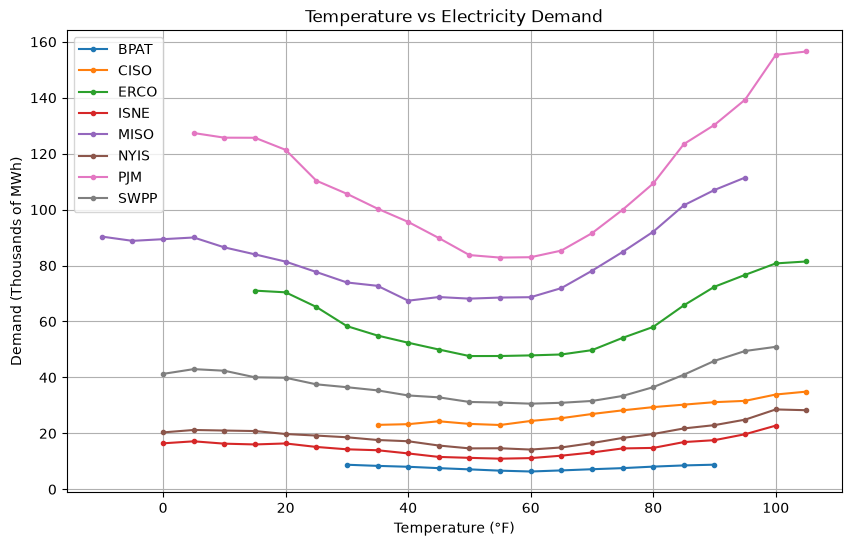

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data
df = pd.read_csv("../data/processed/eia_with_weather.csv")

# Regions to plot
regions = ["BPAT", "CISO", "ERCO", "ISNE", "MISO", "NYIS", "PJM", "SWPP"]

# Create the graph
plt.figure(figsize=(10, 6))

df["temp_bin"] = (df["temperature_F"] / 5).round() * 5
df = (
    df.groupby(["region", "temp_bin"])["demand_mwh"]
      .median()
      .reset_index()
)
# Plot one line for each region
for region in regions:
    region_data = df[df["region"] == region]
    region_data = region_data.sort_values("temp_bin")
    plt.plot(
        region_data["temp_bin"],
        region_data["demand_mwh"] / 1000,
        marker="o",
        markersize=3,    
        linewidth=1.5,
        label=region
    )

# Add labels
plt.title("Temperature vs Electricity Demand")
plt.xlabel("Temperature (°F)")
plt.ylabel("Demand (Thousands of MWh)")
plt.legend()
plt.grid(True)

# Show the graph
plt.show()